# EDA: Seattle Bus Delay Dataset

Goal: quick health check of the processed dataset and basic signal checks (rain vs. dry, routes, time-of-day).

In [53]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_context('talk')
pd.set_option('display.max_columns', 30)

DATA_PATH = Path('..') / 'data' / 'processed' / 'dataset.csv'
assert DATA_PATH.exists(), f"Missing file: {DATA_PATH}"

df = pd.read_csv(DATA_PATH)
print(df.shape)
df.head()

(8674, 22)


,stop_id,route_id,route_short_name,trip_id,vehicle_id,snapshot_ts,gtfs_scheduled_ts,predicted_arrival_ts,delay_min,hour_of_day,day_of_week,is_weekend,is_peak_hour,month,date,hour_bucket,status,temperature_c,precipitation_mm,wind_speed_kmh,weather_code,is_raining
0,1_10912,1_100162,271,1_569496989,1_7976364,1773333401,1.773334e+09,1773333660,0.00,9.0,3.0,0,1,3.0,2026-03-12,2026-03-12 09:00,default,6.7,0.0,12.0,3,0
1,1_9605,1_100259,67,1_761384699,1_7975715,1773333401,1.773333e+09,1773333577,7.62,9.0,3.0,0,1,3.0,2026-03-12,2026-03-12 09:00,default,6.7,0.0,12.0,3,0
2,1_22196,1_102736,H Line,1_694057749,1_6068,1773333401,1.773333e+09,1773333443,-0.27,9.0,3.0,0,1,3.0,2026-03-12,2026-03-12 09:00,default,6.7,0.0,12.0,3,0
3,1_320,40_100240,554,40_736592599,40_9649,1773333401,1.773333e+09,1773333492,3.20,9.0,3.0,0,1,3.0,2026-03-12,2026-03-12 09:00,default,6.7,0.0,12.0,3,0
4,1_575,1_100028,13,1_605109669,1_7183,1773333401,1.773333e+09,1773333439,6.32,9.0,3.0,0,1,3.0,2026-03-12,2026-03-12 09:00,default,6.7,0.0,12.0,3,0


In [54]:
# Basic info and missingness
print(df.dtypes)
print('\nMissing values per column:')
print(df.isna().sum())

stop_id                  object
route_id                 object
route_short_name         object
trip_id                  object
vehicle_id               object
snapshot_ts               int64
gtfs_scheduled_ts       float64
predicted_arrival_ts      int64
delay_min               float64
hour_of_day             float64
day_of_week             float64
is_weekend                int64
is_peak_hour              int64
month                   float64
date                     object
hour_bucket              object
status                   object
temperature_c           float64
precipitation_mm        float64
wind_speed_kmh          float64
weather_code              int64
is_raining                int64
dtype: object

Missing values per column:
stop_id                 0
route_id                0
route_short_name        0
trip_id                 0
vehicle_id              0
snapshot_ts             0
gtfs_scheduled_ts       0
predicted_arrival_ts    0
delay_min               0
hour_of_day         

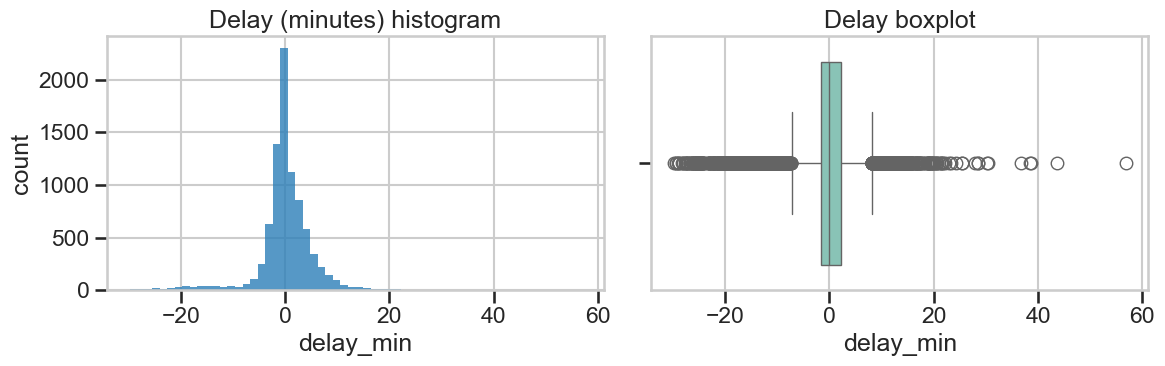

count    8674.000000
mean        0.156509
std         5.397108
min       -29.830000
25%        -1.520000
50%         0.000000
75%         2.320000
max        56.820000
Name: delay_min, dtype: float64


In [55]:
# Delay distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(df['delay_min'], bins=60, color='#2c7fb8', alpha=0.8)
axes[0].set_title('Delay (minutes) histogram')
axes[0].set_xlabel('delay_min')
axes[0].set_ylabel('count')

sns.boxplot(x='delay_min', data=df, ax=axes[1], color='#7fcdbb')
axes[1].set_title('Delay boxplot')
plt.tight_layout()
plt.show()

print(df['delay_min'].describe())

            count      mean  median       std    min    max
is_raining                                                 
dry          5451  0.025792     0.0  5.384857 -29.83  43.55
rain         3223  0.377589     0.0  5.411419 -28.00  56.82


/var/folders/5h/3qm4ghsx5335mg6rwp7lw68w0000gn/T/ipykernel_21064/2533216331.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='is_raining', y='delay_min', palette=['#74add1','#f46d43'])


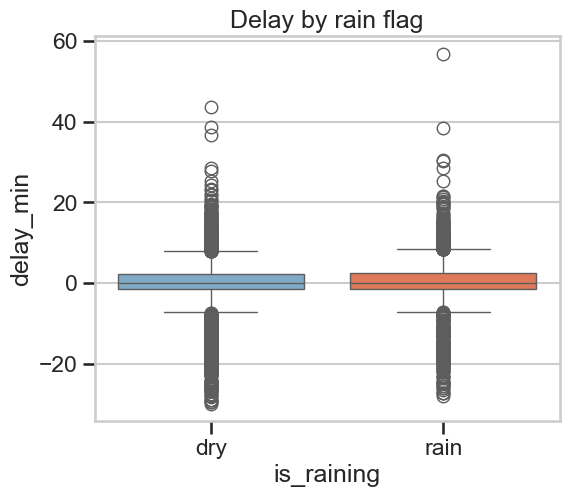

In [56]:
# Rain vs. dry comparison
rain_stats = (
    df.groupby('is_raining')['delay_min']
      .agg(['count','mean','median','std','min','max'])
      .rename(index={0:'dry',1:'rain'})
)
print(rain_stats)

plt.figure(figsize=(6,5))
sns.boxplot(data=df, x='is_raining', y='delay_min', palette=['#74add1','#f46d43'])
plt.xticks([0,1], ['dry','rain'])
plt.title('Delay by rain flag')
plt.show()

count    8674.000000
mean       -1.578810
std         1.646302
min        -5.000000
25%        -2.683333
50%        -1.666667
75%        -0.733333
max         5.000000
Name: snapshot_pred_diff_min, dtype: float64
Share within ±5 min: 100.0%


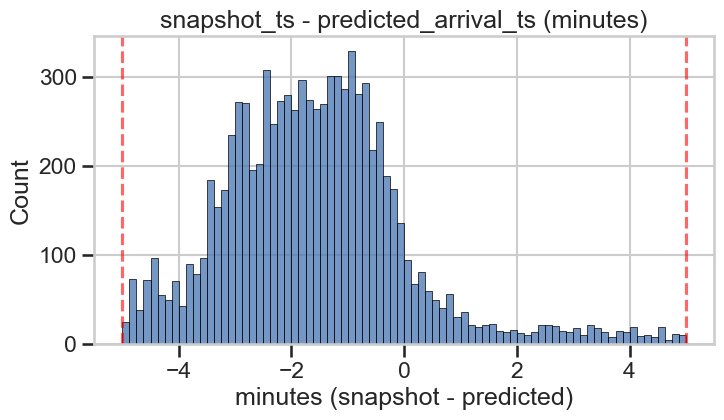

In [57]:
# Snapshot vs predicted arrival sanity check
# Expect snapshot_ts ≈ predicted_arrival_ts when bus is at stop.
df['snapshot_pred_diff_min'] = (df['snapshot_ts'] - df['predicted_arrival_ts']) / 60
print(df['snapshot_pred_diff_min'].describe())

within5 = (df['snapshot_pred_diff_min'].abs() <= 5).mean()*100
print(f"Share within ±5 min: {within5:.1f}%")

plt.figure(figsize=(8,4))
sns.histplot(df['snapshot_pred_diff_min'], bins=80, color='#4575b4')
plt.axvline(5, color='red', linestyle='--', alpha=0.6)
plt.axvline(-5, color='red', linestyle='--', alpha=0.6)
plt.title('snapshot_ts - predicted_arrival_ts (minutes)')
plt.xlabel('minutes (snapshot - predicted)')
plt.show()

                  count      mean  median
route_short_name                         
F Line              510  0.049510   0.000
14                  338  0.933343   0.520
H Line              312  0.125224  -0.550
181                 281 -4.415267  -1.530
7                   256  0.422422  -0.515
40                  255  2.457373   2.020
60                  250  5.114640   4.095
150                 237  0.808017   0.000
D Line              229  1.556070   1.170
161                 223 -0.581614   0.000
E Line              211 -0.669005  -0.920
2                   202 -5.822228  -2.065
550                 195  0.803641   0.720
372                 193  2.631762   2.550
70                  184  0.807989   0.225


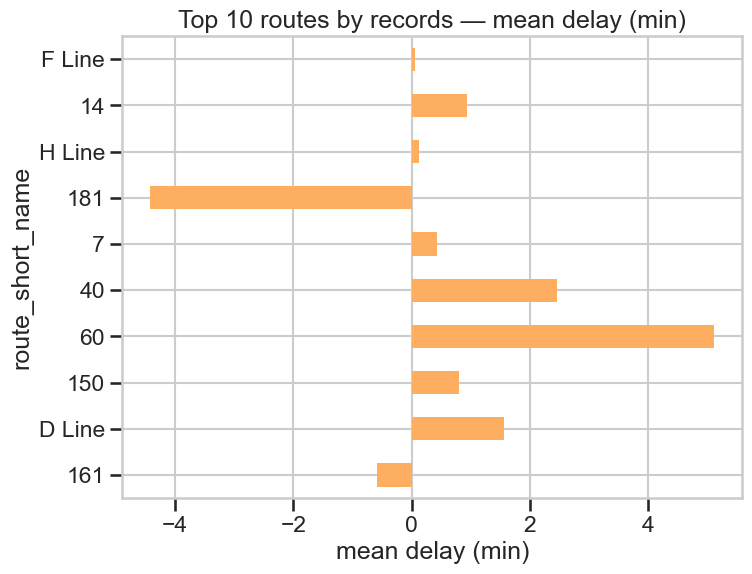

In [58]:
# Route-level volume and mean delay
route_stats = (
    df.groupby('route_short_name')['delay_min']
      .agg(['count','mean','median'])
      .sort_values('count', ascending=False)
)
print(route_stats.head(15))

plt.figure(figsize=(8,6))
route_stats.head(10)['mean'].plot(kind='barh', color='#fdae61')
plt.gca().invert_yaxis()
plt.title('Top 10 routes by records — mean delay (min)')
plt.xlabel('mean delay (min)')
plt.show()

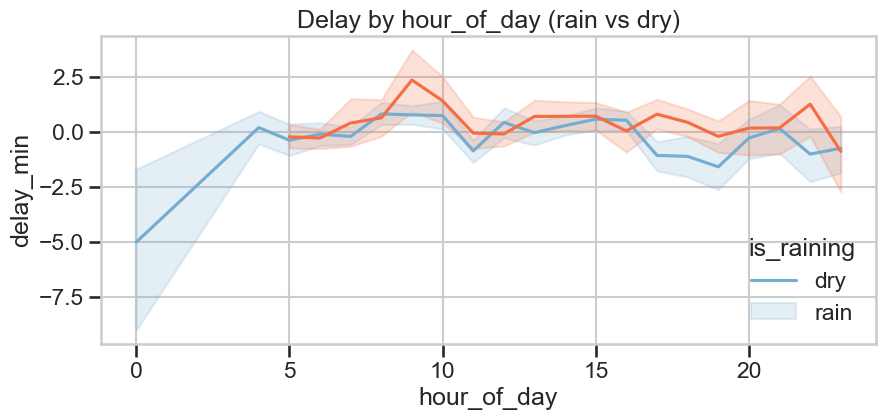

In [59]:
# Time-of-day pattern
plt.figure(figsize=(10,4))
sns.lineplot(data=df, x='hour_of_day', y='delay_min', hue='is_raining', palette=['#74add1','#f46d43'])
plt.title('Delay by hour_of_day (rain vs dry)')
plt.xlabel('hour_of_day')
plt.ylabel('delay_min')
plt.legend(title='is_raining', labels=['dry','rain'])
plt.show()

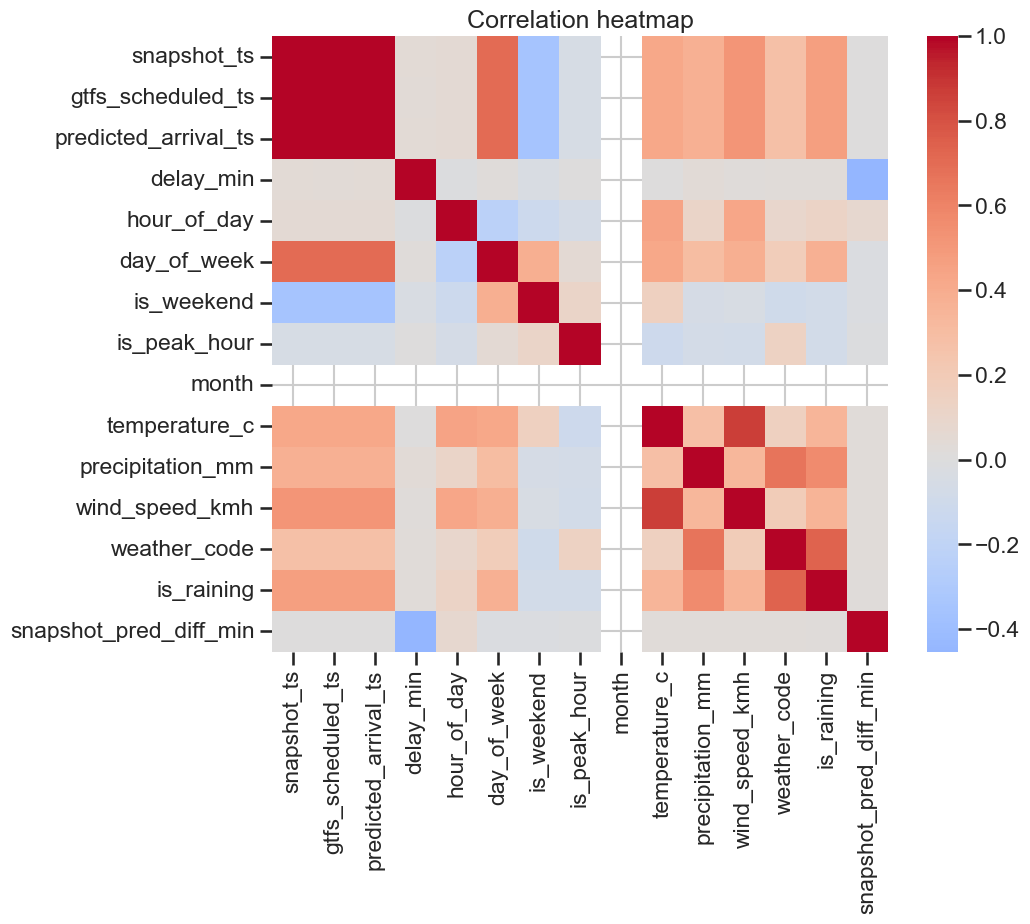

In [61]:
# Correlation heatmap for numeric features
num_cols = df.select_dtypes(include=['float64','int64']).columns
corr = df[num_cols].corr()
plt.figure(figsize=(10,8))
sns.heatmap(corr, cmap='coolwarm', center=0, square=True)
plt.title('Correlation heatmap')
plt.show()

## Notes / To-do
- Consider adding engineered features: route encoding, rain×peak interaction, rolling averages by route/hour.
- Re-run this notebook after any pipeline change to confirm distributions and sanity checks remain stable.